In [ ]:
!pip install xgboost opencv-python kagglehub -q

In [ ]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

os.makedirs("outputs", exist_ok=True)

In [ ]:
#path
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset Path :", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path : /kaggle/input/chest-xray-pneumonia


In [ ]:
#classes
classes = {
    'NORMAL': 0,
    'PNEUMONIA': 1
}

dec = {
    0: 'Normal',
    1: 'Pneumonia'
}

IMG_SIZE = 128

In [ ]:
#load dataset
train_path = os.path.join(
    path,
    "chest_xray",
    "train"
)

test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)

def load_images(folder_path):

    X = []
    Y = []

    for cls, label in classes.items():

        class_path = os.path.join(
            folder_path,
            cls
        )

        for filename in os.listdir(class_path):

            img_path = os.path.join(
                class_path,
                filename
            )

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            if img is not None:

                img = cv2.resize(
                    img,
                    (IMG_SIZE, IMG_SIZE)
                )

                img = img.flatten() / 255.0

                X.append(img)

                Y.append(label)

    return np.array(X, dtype=np.float32), np.array(Y)


print("Loading Training Images...")

X_train, Y_train = load_images(train_path)

print("Loading Testing Images...")

X_test, Y_test = load_images(test_path)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)
print("\nNORMAL     :", np.sum(Y_train==0))
print("PNEUMONIA :", np.sum(Y_train==1))

Loading Training Images...
Loading Testing Images...

Training Shape : (5216, 16384)
Testing Shape  : (624, 16384)

NORMAL     : 1341
PNEUMONIA : 3875


In [ ]:
#training split
train_sizes = [0.2, 0.4, 0.6, 0.8]


TRAINING DATA USED : 20%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 1043
Testing Samples  : 624

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 0.9913710450623202
Testing Accuracy  : 0.7724358974358975
F1 Score          : 0.7470287096110311
Sensitivity       : 0.9769230769230769
Specificity       : 0.43162393162393164

Classification Report:

              precision    recall  f1-score   support

      Normal       0.92      0.43      0.59       234
   Pneumonia       0.74      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.83      0.70      0.72       624
weighted avg       0.81      0.77      0.75       624



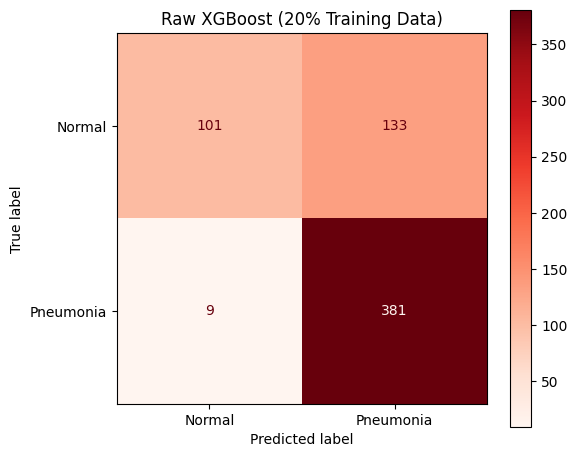


TRAINING DATA USED : 40%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 2086
Testing Samples  : 624

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 0.9755512943432406
Testing Accuracy  : 0.7836538461538461
F1 Score          : 0.7629094837783701
Sensitivity       : 0.9717948717948718
Specificity       : 0.4700854700854701

Classification Report:

              precision    recall  f1-score   support

      Normal       0.91      0.47      0.62       234
   Pneumonia       0.75      0.97      0.85       390

    accuracy                           0.78       624
   macro avg       0.83      0.72      0.73       624
weighted avg       0.81      0.78      0.76       624



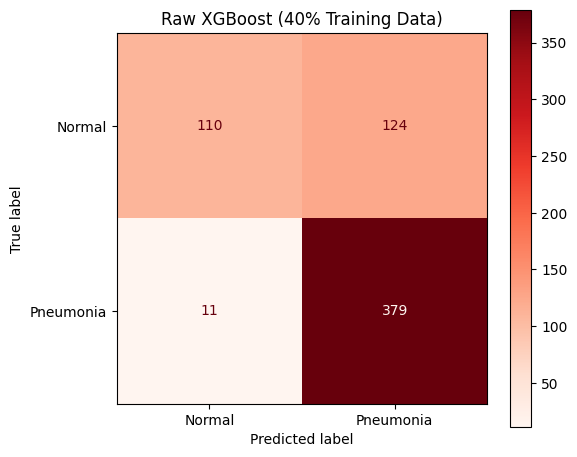


TRAINING DATA USED : 60%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 3129
Testing Samples  : 624

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 0.975071907957814
Testing Accuracy  : 0.7916666666666666
F1 Score          : 0.7725346808109974
Sensitivity       : 0.9743589743589743
Specificity       : 0.48717948717948717

Classification Report:

              precision    recall  f1-score   support

      Normal       0.92      0.49      0.64       234
   Pneumonia       0.76      0.97      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.73      0.75       624
weighted avg       0.82      0.79      0.77       624



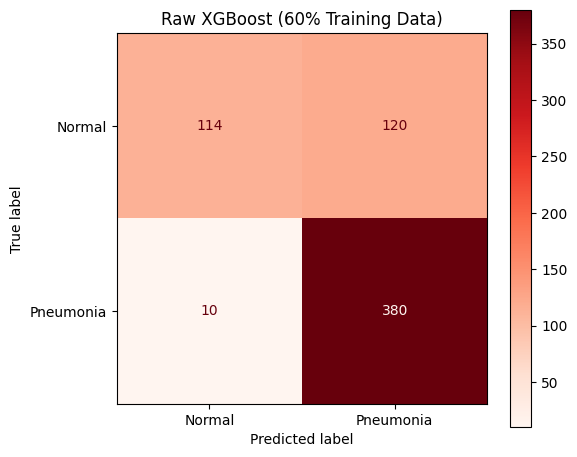


TRAINING DATA USED : 80%
TESTING DATA USED  : 100% Official Test Set
Training Samples : 4172
Testing Samples  : 624

Training Raw XGBoost Model...
Training Completed
Training Accuracy : 0.9712368168744008
Testing Accuracy  : 0.7900641025641025
F1 Score          : 0.7716141433510197
Sensitivity       : 0.9692307692307692
Specificity       : 0.49145299145299143

Classification Report:

              precision    recall  f1-score   support

      Normal       0.91      0.49      0.64       234
   Pneumonia       0.76      0.97      0.85       390

    accuracy                           0.79       624
   macro avg       0.83      0.73      0.74       624
weighted avg       0.81      0.79      0.77       624



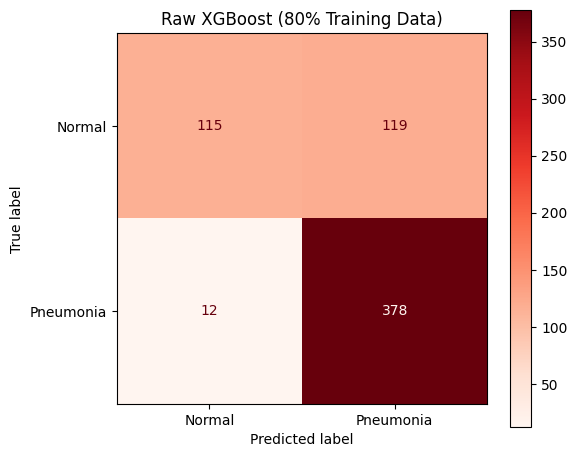

In [ ]:
#xgboost_training
train_acc_list = []

test_acc_list = []

f1_list = []

sensitivity_list = []

specificity_list = []

labels = []

for train_size in train_sizes:

    print("\n======================================")
    print(f"TRAINING DATA USED : {int(train_size*100)}%")
    print("TESTING DATA USED  : 100% Official Test Set")
    print("======================================")

    # TAKE SUBSET OF TRAINING DATA
    xtrain, _, ytrain, _ = train_test_split(
        X_train,
        Y_train,
        train_size=train_size,
        random_state=42,
        stratify=Y_train
    )

    print("Training Samples :", xtrain.shape[0])
    print("Testing Samples  :", X_test.shape[0])

    # XGBOOST MODEL
    xgb = XGBClassifier(

        n_estimators=80,

        max_depth=3,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.3,

        scale_pos_weight=np.sum(Y_train==0)/np.sum(Y_train==1),

        tree_method='hist',

        reg_lambda=5,

        eval_metric='logloss',

        random_state=42,

        n_jobs=-1,

        verbosity=0
    )

    print("\nTraining Raw XGBoost Model...")

    xgb.fit(
        xtrain,
        ytrain
    )

    print("Training Completed")

    # PREDICTIONS
    train_pred = xgb.predict(xtrain)

    test_pred = xgb.predict(X_test)

    # METRICS
    train_acc = accuracy_score(
        ytrain,
        train_pred
    )

    test_acc = accuracy_score(
        Y_test,
        test_pred
    )

    f1 = f1_score(
        Y_test,
        test_pred,
        average='weighted'
    )

    cm = confusion_matrix(
        Y_test,
        test_pred
    )

    sensitivity = (
        cm[1,1] /
        (cm[1,1] + cm[1,0])
    )

    specificity = (
        cm[0,0] /
        (cm[0,0] + cm[0,1])
    )

    print("Training Accuracy :", train_acc)
    print("Testing Accuracy  :", test_acc)
    print("F1 Score          :", f1)
    print("Sensitivity       :", sensitivity)
    print("Specificity       :", specificity)

    # STORE RESULTS
    train_acc_list.append(train_acc)

    test_acc_list.append(test_acc)

    f1_list.append(f1)

    sensitivity_list.append(sensitivity)
    specificity_list.append(specificity)

    labels.append(
        f"{int(train_size*100)}%"
    )

    # CLASSIFICATION REPORT
    print("\nClassification Report:\n")

    print(
        classification_report(
            Y_test,
            test_pred,
            target_names=list(dec.values())
        )
    )

    # CONFUSION MATRIX
    fig, ax = plt.subplots(figsize=(6,5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(dec.values())
    )

    disp.plot(
        ax=ax,
        cmap='Reds',
        colorbar=True
    )

    plt.title(
        f"Raw XGBoost ({int(train_size*100)}% Training Data)"
    )

    plt.tight_layout()

    plt.show()

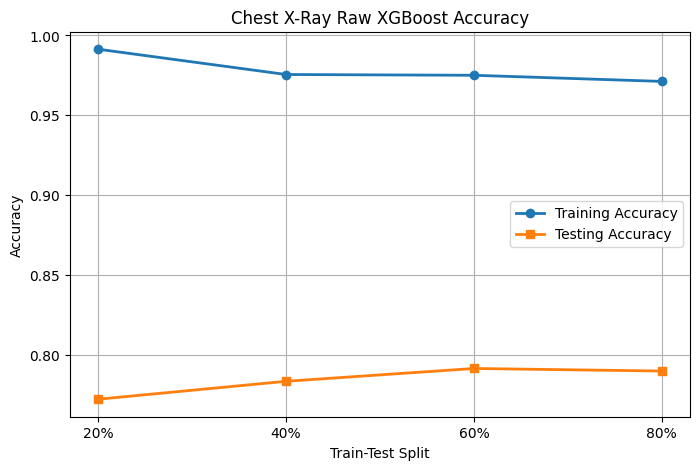

In [ ]:
#accuracy plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_acc_list,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    labels,
    test_acc_list,
    marker='s',
    linewidth=2,
    label='Testing Accuracy'
)

plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy")
plt.title("Chest X-Ray Raw XGBoost Accuracy")
plt.legend()
plt.grid(True)
plt.show()

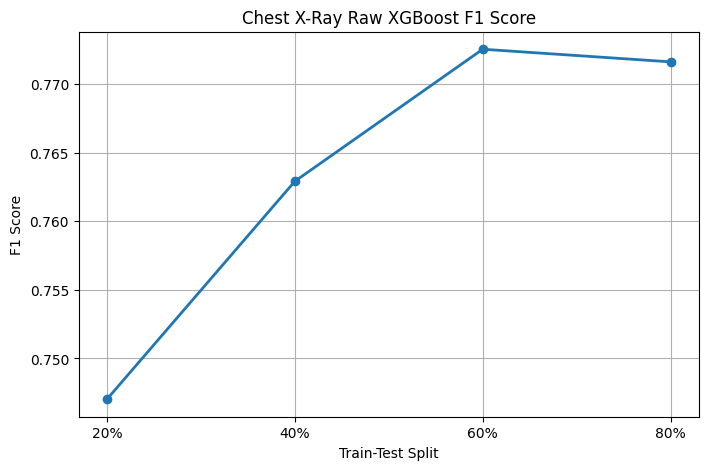

In [ ]:
#f1 plot
plt.figure(figsize=(8,5))

plt.plot(
    labels,
    f1_list,
    marker='o',
    linewidth=2
)

plt.xlabel("Train-Test Split")

plt.ylabel("F1 Score")

plt.title("Chest X-Ray Raw XGBoost F1 Score")

plt.grid(True)

plt.show()

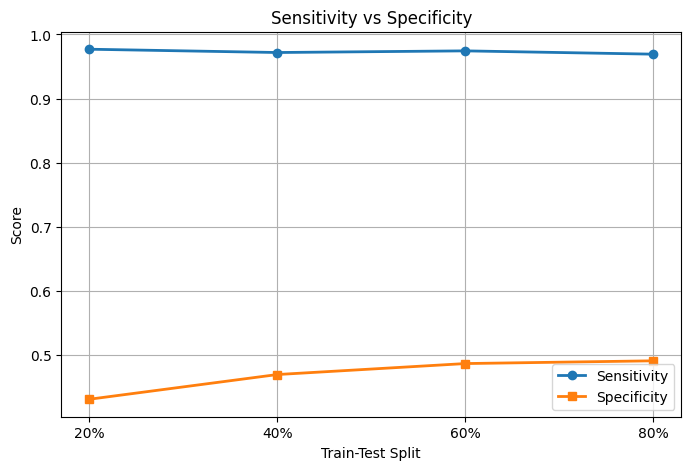

In [ ]:
#sensitivity and specificity

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    sensitivity_list,
    marker='o',
    linewidth=2,
    label='Sensitivity'
)

plt.plot(
    labels,
    specificity_list,
    marker='s',
    linewidth=2,
    label='Specificity'
)

plt.xlabel("Train-Test Split")
plt.ylabel("Score")
plt.title("Sensitivity vs Specificity")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# CELL 11 — RESULTS TABLE
# ============================================

results_df = pd.DataFrame({

    'Train-Test Split': labels,

    'Training Accuracy': train_acc_list,

    'Testing Accuracy': test_acc_list,

    'F1 Score': f1_list,

    'Sensitivity': sensitivity_list,

    'Specificity': specificity_list
})

print(results_df)

  Train-Test Split  Training Accuracy  Testing Accuracy  F1 Score  \
0              20%           0.991371          0.772436  0.747029   
1              40%           0.975551          0.783654  0.762909   
2              60%           0.975072          0.791667  0.772535   
3              80%           0.971237          0.790064  0.771614   

   Sensitivity  Specificity  
0     0.976923     0.431624  
1     0.971795     0.470085  
2     0.974359     0.487179  
3     0.969231     0.491453  


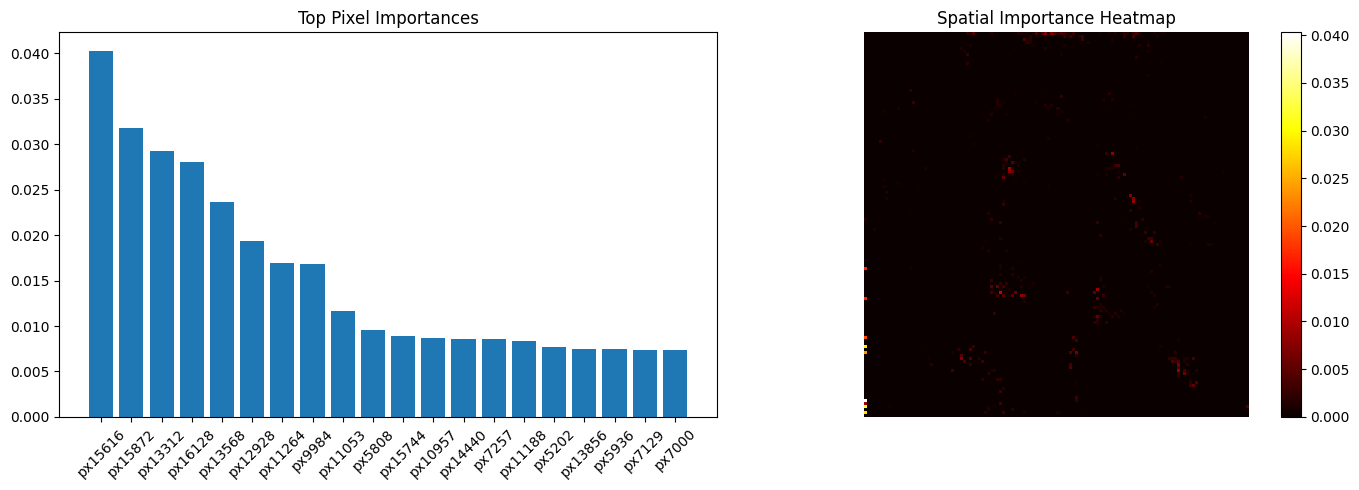

In [ ]:
#feature_importance
importances = xgb.feature_importances_

importance_map = np.zeros(
    IMG_SIZE * IMG_SIZE
)

importance_map[:len(importances)] = importances

importance_map = importance_map.reshape(
    IMG_SIZE,
    IMG_SIZE
)

top_idx = np.argsort(
    importances
)[::-1][:20]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# TOP FEATURES
axes[0].bar(
    range(20),
    importances[top_idx]
)

axes[0].set_xticks(range(20))

axes[0].set_xticklabels(
    [f"px{idx}" for idx in top_idx],
    rotation=45
)

axes[0].set_title(
    "Top Pixel Importances"
)

# HEATMAP
im = axes[1].imshow(
    importance_map,
    cmap='hot'
)

axes[1].set_title(
    "Spatial Importance Heatmap"
)

axes[1].axis('off')

plt.colorbar(im)

plt.tight_layout()

plt.show()

In [ ]:
#sample predictions
test_path = os.path.join(
    path,
    "chest_xray",
    "test"
)

def display_samples(folder, title, num_samples=9):

    valid_ext = (
        '.jpg',
        '.jpeg',
        '.png'
    )

    imgs = [
        f for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]

    imgs = imgs[:num_samples]

    if len(imgs) == 0:
        return

    cols = min(3, len(imgs))

    rows = (len(imgs) + cols - 1) // cols

    plt.figure(figsize=(12,4*rows))

    for i, filename in enumerate(imgs, 1):

        img_path = os.path.join(
            folder,
            filename
        )

        img = cv2.imread(
            img_path,
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        pred = xgb.predict(
            [img.flatten()/255.0]
        )[0]

        plt.subplot(rows, cols, i)

        plt.imshow(
            img,
            cmap='gray'
        )

        plt.title(
            dec[pred],
            color='green' if pred == 0 else 'red'
        )

        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

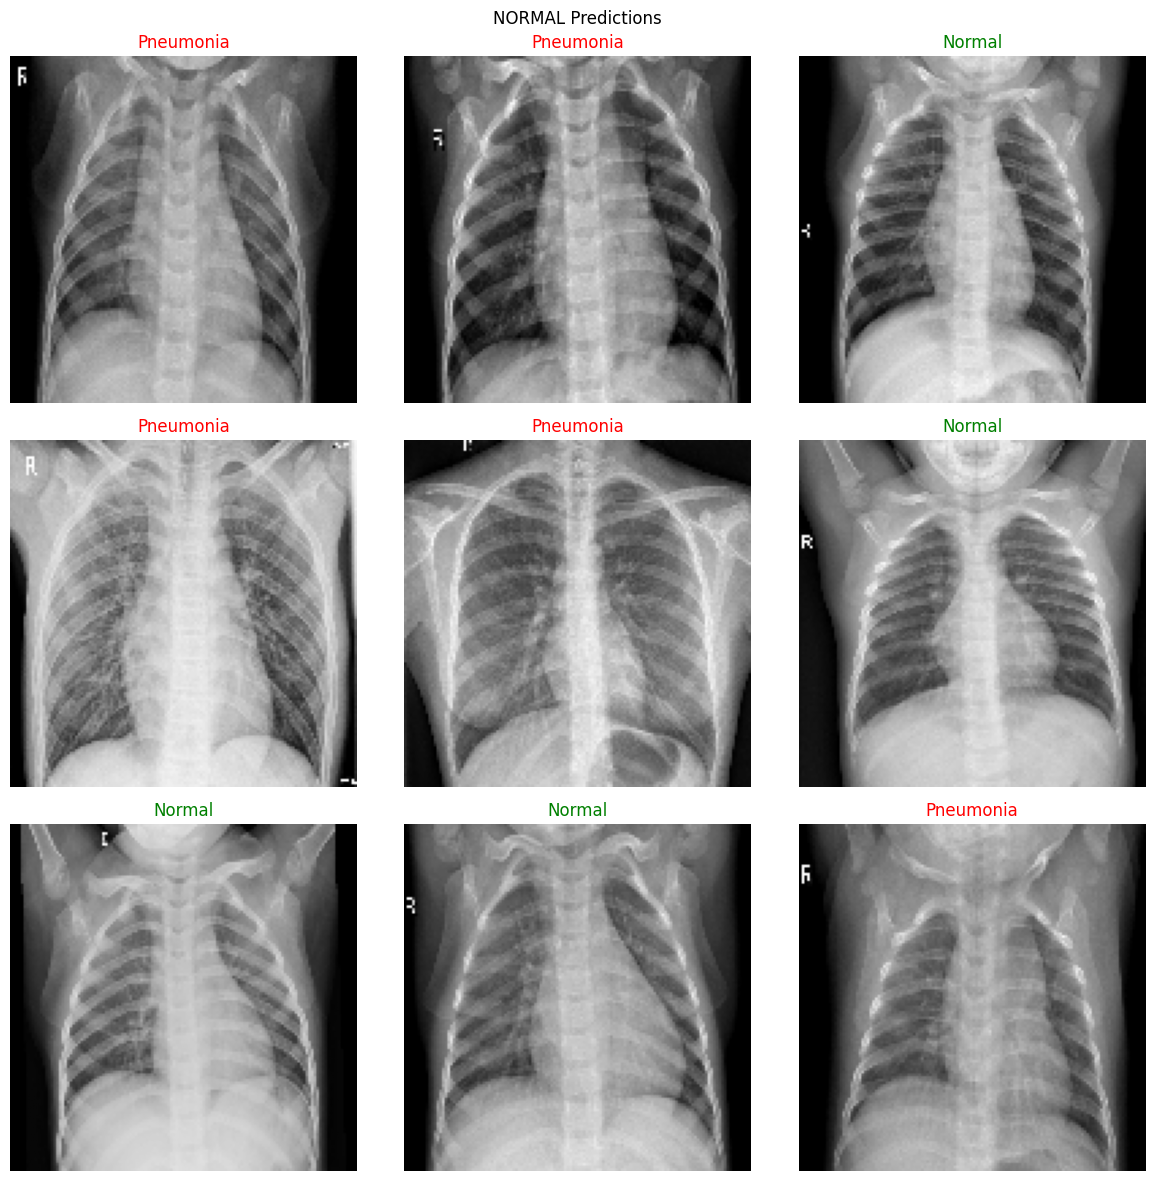

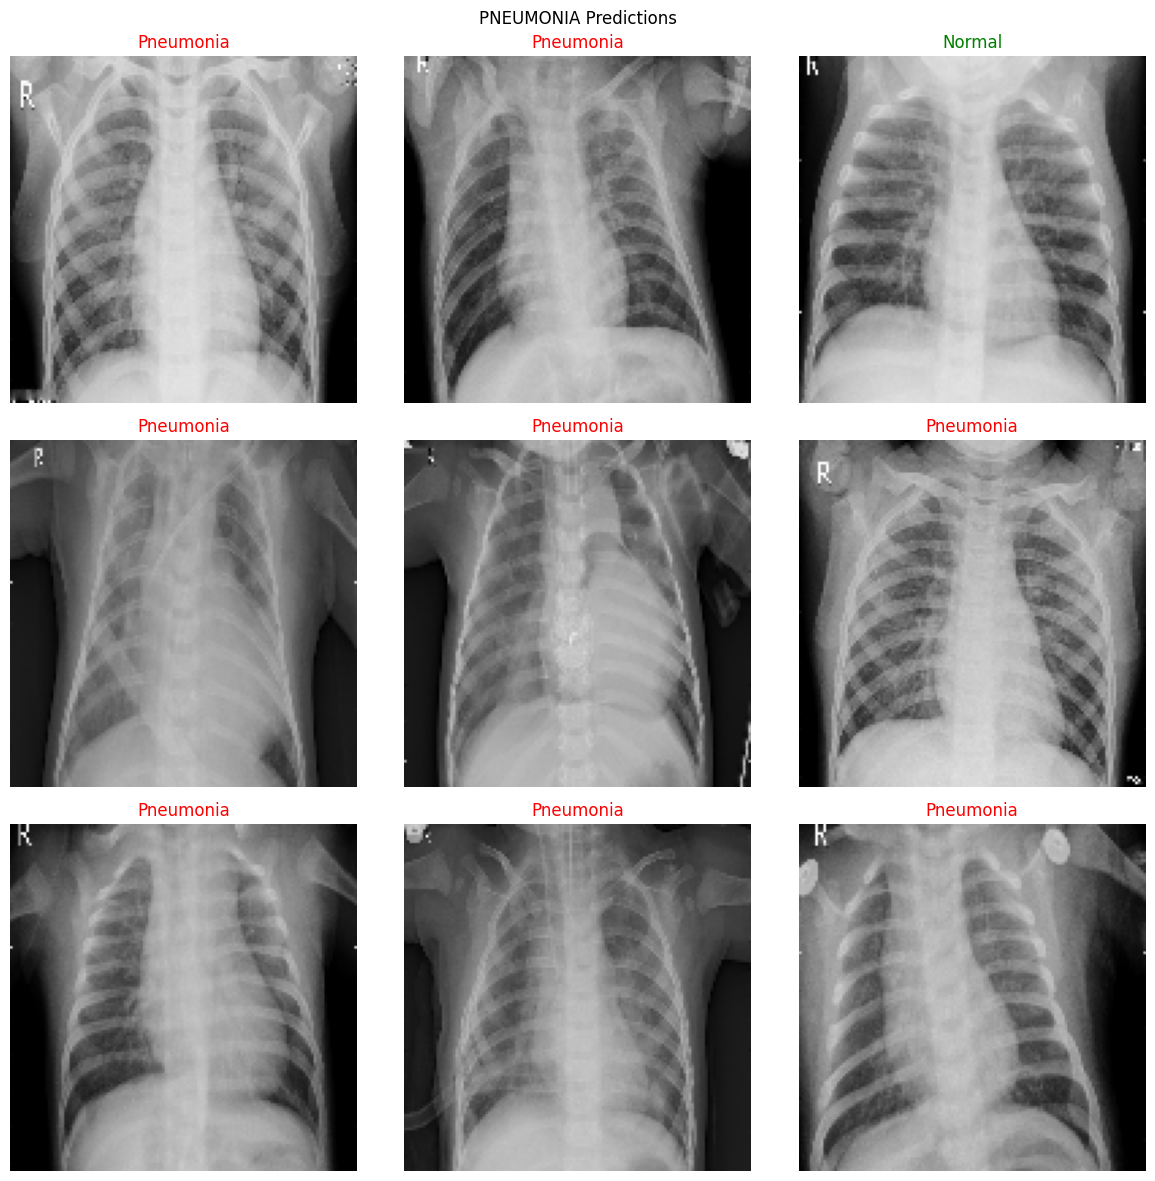

In [ ]:
#display_samples
for cls_folder in classes.keys():

    folder_path = os.path.join(
        test_path,
        cls_folder
    )

    if os.path.isdir(folder_path):

        display_samples(
            folder_path,
            f"{cls_folder} Predictions"
        )

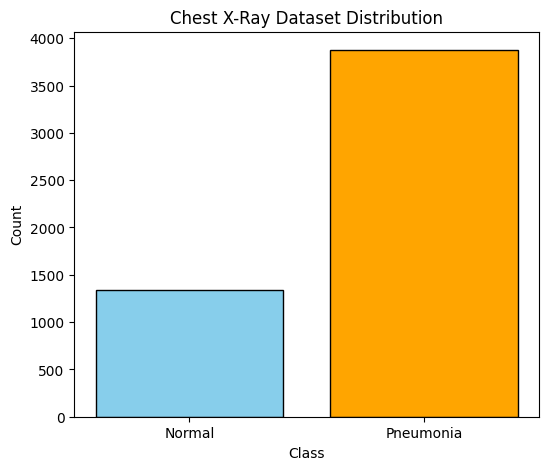

In [ ]:
#dataset_distribution
plt.figure(figsize=(6,5))

for label, color in zip(
    [0,1],
    ['skyblue', 'orange']
):

    plt.bar(
        dec[label],
        int(np.sum(Y_train == label)),
        color=color,
        edgecolor='black'
    )

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Chest X-Ray Dataset Distribution")
plt.show()